## 0. 분석 환경 설정

원본 데이터 경로, 그림 저장 경로, 표 저장 경로를 설정한다.  
이후 생성되는 시각화와 요약표는 `analysis/figures/raw`, `analysis/tables/raw` 아래에 저장된다.

In [2]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "src" / "data" / "raw"
FIGURE_DIR = PROJECT_ROOT / "analysis" / "figures" / "raw"
TABLE_DIR = PROJECT_ROOT / "analysis" / "tables" / "raw"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

KOREAN_FONT_PATH = Path("C:/Windows/Fonts/malgun.ttf")
fm.fontManager.addfont(str(KOREAN_FONT_PATH))
KOREAN_FONT = fm.FontProperties(fname=str(KOREAN_FONT_PATH))
KOREAN_FONT_NAME = KOREAN_FONT.get_name()

sns.set_theme(
    style="whitegrid",
    font=KOREAN_FONT_NAME,
    rc={"axes.unicode_minus": False},
)
plt.rcParams["font.family"] = KOREAN_FONT_NAME
plt.rcParams["axes.unicode_minus"] = False

def apply_korean_font(ax):
    ax.title.set_fontproperties(KOREAN_FONT)
    ax.xaxis.label.set_fontproperties(KOREAN_FONT)
    ax.yaxis.label.set_fontproperties(KOREAN_FONT)
    for text in ax.get_xticklabels() + ax.get_yticklabels() + ax.texts:
        text.set_fontproperties(KOREAN_FONT)
    return ax

print("사용 폰트:", KOREAN_FONT_NAME)

사용 폰트: Malgun Gothic


## 1. 분석 대상 raw 로드

CCTV, 스마트가로등, 어린이보호구역, 도보 네트워크 raw를 불러온다.  
출력되는 shape를 통해 raw별 row 수와 column 수 차이를 먼저 확인한다.

In [3]:
TARGET_FILES = [
    "서울시CCTV정보.xlsx",
    "전국스마트가로등표준데이터.csv",
    "전국어린이보호구역표준데이터.csv",
    "서울시 자치구별 도보 네트워크 공간정보.csv",
]

SEOUL_GU = [
    "강남구",
    "강동구",
    "강북구",
    "강서구",
    "관악구",
    "광진구",
    "구로구",
    "금천구",
    "노원구",
    "도봉구",
    "동대문구",
    "동작구",
    "마포구",
    "서대문구",
    "서초구",
    "성동구",
    "성북구",
    "송파구",
    "양천구",
    "영등포구",
    "용산구",
    "은평구",
    "종로구",
    "중구",
    "중랑구",
]


def read_raw(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".xlsx":
        return pd.read_excel(path)
    for enc in ["utf-8-sig", "cp949", "euc-kr"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)


raw_frames = {}
for file_name in TARGET_FILES:
    path = RAW_DIR / file_name
    raw_frames[file_name] = read_raw(path)
    print(file_name, raw_frames[file_name].shape)

c:\Users\82102\Desktop\seoul-walk-platform\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


서울시CCTV정보.xlsx (57760, 14)
전국스마트가로등표준데이터.csv (12728, 27)
전국어린이보호구역표준데이터.csv (14599, 14)
서울시 자치구별 도보 네트워크 공간정보.csv (491082, 23)


## 2. 자치구 추출 및 자치구별 count 생성

raw마다 자치구 컬럼명이 다르거나 주소 안에 자치구가 들어 있으므로, 공통 함수로 `OO구`를 추출한다.  
이후 raw별/자치구별 row 수를 계산해 `raw_gu_count.csv`로 저장한다.

In [24]:
def extract_gu_from_text(value):
    if pd.isna(value):
        return np.nan
    text = str(value)
    match = re.search(r"([가-힣]+구)", text)
    if match and match.group(1) in SEOUL_GU:
        return match.group(1)
    return np.nan


def infer_gu(df: pd.DataFrame) -> pd.Series:
    gu_cols = [
        c for c in df.columns if c in ["구", "자치구", "시군구명", "시군구", "구명"]
    ]
    if gu_cols:
        return df[gu_cols[0]].astype(str).str.extract(r"([가-힣]+구)")[0]

    address_cols = [
        c for c in df.columns if "주소" in c or "소재지" in c or "도로명" in c
    ]
    if address_cols:
        combined = df[address_cols].astype(str).agg(" ".join, axis=1)
        return combined.apply(extract_gu_from_text)

    return pd.Series(np.nan, index=df.index)


gu_count_rows = []
extraction_summary_rows = []

for raw_name, df in raw_frames.items():
    gu = infer_gu(df)
    valid_gu = gu.dropna()
    extraction_summary_rows.append(
        {
            "raw_name": raw_name,
            "raw_rows": len(df),
            "gu_extracted_rows": int(valid_gu.isin(SEOUL_GU).sum()),
            "gu_extracted_rate": float(valid_gu.isin(SEOUL_GU).sum() / len(df)) if len(df) else 0,
            "unique_gu": int(valid_gu[valid_gu.isin(SEOUL_GU)].nunique()),
        }
    )
    temp = (
        pd.DataFrame({"raw_name": raw_name, "gu": gu})
        .dropna(subset=["gu"])
        .query("gu in @SEOUL_GU")
        .groupby(["raw_name", "gu"])
        .size()
        .reset_index(name="count")
    )
    gu_count_rows.append(temp)

gu_count = pd.concat(gu_count_rows, ignore_index=True)
gu_count.to_csv(TABLE_DIR / "raw_gu_count.csv", index=False, encoding="utf-8-sig")

extraction_summary = pd.DataFrame(extraction_summary_rows)

raw_gu_summary = (
    gu_count.groupby("raw_name")
    .agg(
        gu_count=("gu", "nunique"),
        total_rows=("count", "sum"),
        min_gu_count=("count", "min"),
        max_gu_count=("count", "max"),
    )
    .reset_index()
)

display(extraction_summary)
display(raw_gu_summary)
display(gu_count.sort_values(["raw_name", "gu"]).head(40))

,raw_name,gu_count,total_rows,min_gu_count,max_gu_count
0,서울시 자치구별 도보 네트워크 공간정보.csv,25,491082,12544,29134
1,서울시CCTV정보.xlsx,24,53217,2,6324
2,전국스마트가로등표준데이터.csv,8,362,1,178
3,전국어린이보호구역표준데이터.csv,25,1891,31,262


,raw_name,gu,count
57,서울시 자치구별 도보 네트워크 공간정보.csv,강남구,29134
58,서울시 자치구별 도보 네트워크 공간정보.csv,강동구,19274
59,서울시 자치구별 도보 네트워크 공간정보.csv,강북구,18982
60,서울시 자치구별 도보 네트워크 공간정보.csv,강서구,18803
61,서울시 자치구별 도보 네트워크 공간정보.csv,관악구,19532
62,서울시 자치구별 도보 네트워크 공간정보.csv,광진구,16288
63,서울시 자치구별 도보 네트워크 공간정보.csv,구로구,20276
64,서울시 자치구별 도보 네트워크 공간정보.csv,금천구,12544
65,서울시 자치구별 도보 네트워크 공간정보.csv,노원구,24226
66,서울시 자치구별 도보 네트워크 공간정보.csv,도봉구,14886


## 3. raw별 전체 규모 비교

각 raw 파일의 전체 row 수를 bar chart로 비교한다.  
이 결과로 CCTV처럼 row 수가 큰 raw가 단순 count 비교에서 과도하게 강조될 수 있는지 확인한다.

,raw_name,rows,columns
3,서울시 자치구별 도보 네트워크 공간정보.csv,491082,23
0,서울시CCTV정보.xlsx,57760,14
2,전국어린이보호구역표준데이터.csv,14599,14
1,전국스마트가로등표준데이터.csv,12728,27


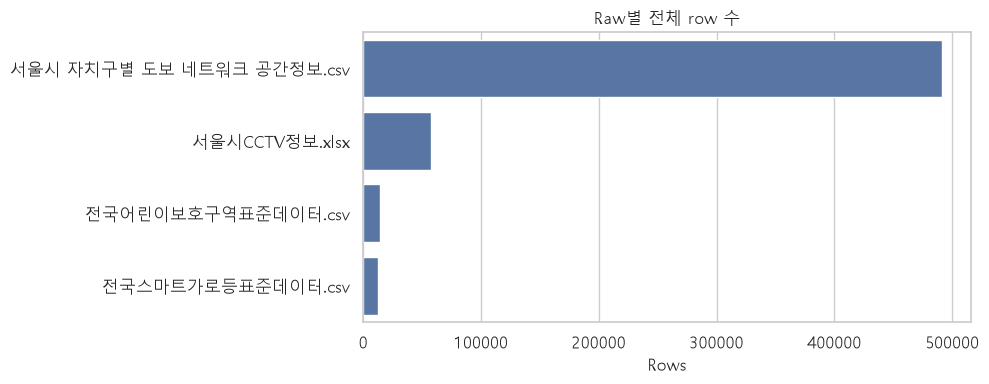

In [19]:
raw_size = pd.DataFrame(
    [
        {"raw_name": name, "rows": len(df), "columns": len(df.columns)}
        for name, df in raw_frames.items()
    ]
).sort_values("rows", ascending=False)

display(raw_size)

plt.figure(figsize=(10, 4))
ax = sns.barplot(data=raw_size, x="rows", y="raw_name")
ax.set_title("Raw별 전체 row 수")
ax.set_xlabel("Rows")
ax.set_ylabel("")
apply_korean_font(ax)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "raw_total_rows.png", dpi=160)
plt.show()

## 4. 자치구별 raw count heatmap

자치구별로 각 raw가 몇 건씩 분포하는지 heatmap으로 확인한다.  
특정 자치구에 데이터가 몰려 있는지, raw별 분포 편차가 큰지 볼 수 있다.

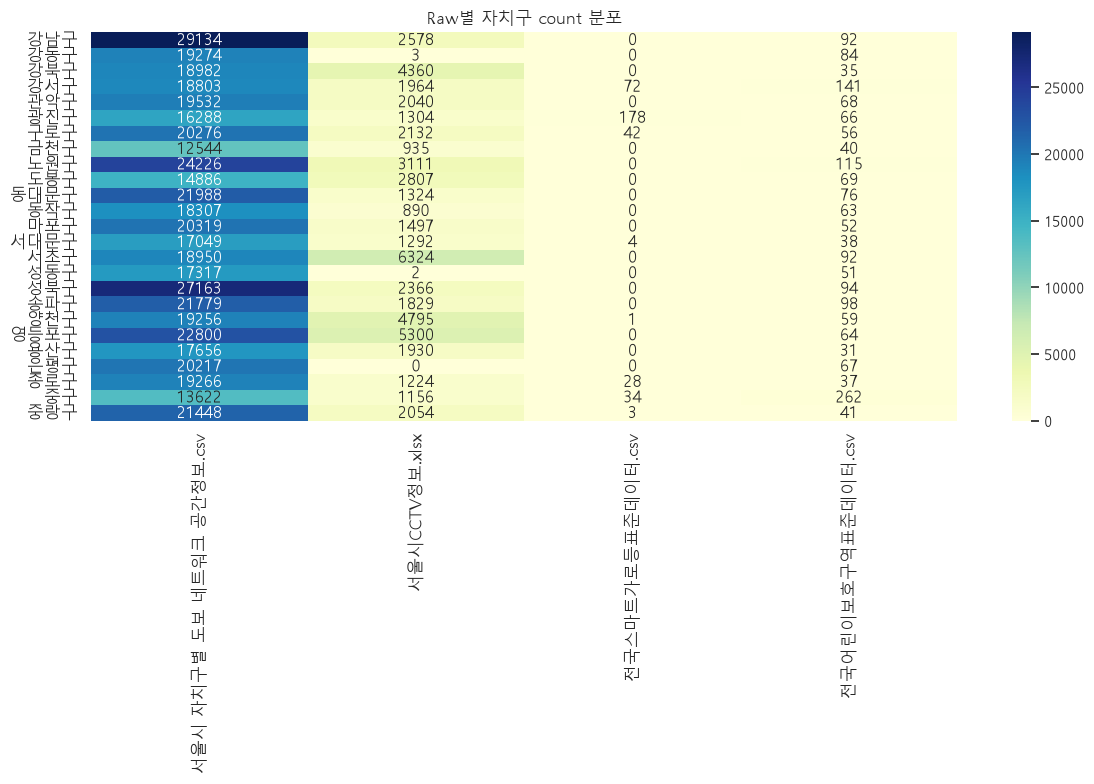

In [20]:
gu_pivot = gu_count.pivot_table(
    index="gu", columns="raw_name", values="count", fill_value=0
).reindex(SEOUL_GU)

plt.figure(figsize=(12, 8))
ax = sns.heatmap(gu_pivot, annot=True, fmt=".0f", cmap="YlGnBu")
ax.set_title("Raw별 자치구 count 분포")
ax.set_xlabel("")
ax.set_ylabel("")
apply_korean_font(ax)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "raw_gu_count_heatmap.png", dpi=160)
plt.show()

## 5. 자치구 분포 편차 요약

raw별 자치구 count의 `min`, `max`, `mean`, `std`, `cv`, `max_min_ratio`를 계산한다.  
`cv`가 클수록 자치구별 편차가 큰 raw로 해석할 수 있다.

In [21]:
dist_summary = (
    gu_count.groupby("raw_name")["count"]
    .agg(["count", "min", "max", "mean", "std"])
    .reset_index()
)

dist_summary["cv"] = dist_summary["std"] / dist_summary["mean"]
dist_summary["max_min_ratio"] = dist_summary["max"] / dist_summary["min"].replace(
    0, np.nan
)

display(dist_summary.sort_values("cv", ascending=False))
dist_summary.to_csv(
    TABLE_DIR / "raw_gu_distribution_summary.csv", index=False, encoding="utf-8-sig"
)

,raw_name,count,min,max,mean,std,cv,max_min_ratio
2,전국스마트가로등표준데이터.csv,8,1,178,45.250,58.818729,1.299861,178.000000
1,서울시CCTV정보.xlsx,24,2,6324,2217.375,1582.541402,0.713700,3162.000000
3,전국어린이보호구역표준데이터.csv,25,31,262,75.640,47.175099,0.623679,8.451613
0,서울시 자치구별 도보 네트워크 공간정보.csv,25,12544,29134,19643.280,3722.540279,0.189507,2.322545


## 6. 면적 대비 density 계산 준비

자치구 면적을 붙여 `count / area_km2` 형태의 밀도 지표를 만들기 위한 단계다.  
현재는 `area_km2`가 비어 있으므로 공식 자치구 면적값을 입력해야 실제 density 비교가 가능하다.

In [26]:
SEOUL_GU_AREA_KM2 = {
    "서초구": 46.97, "강서구": 41.45, "강남구": 39.50, "노원구": 35.46, "송파구": 33.88,
    "은평구": 29.71, "관악구": 29.57, "성북구": 24.59, "강동구": 24.59, "영등포구": 24.55,
    "종로구": 23.91, "마포구": 23.85, "강북구": 23.61, "용산구": 21.87, "도봉구": 20.65,
    "구로구": 20.12, "중랑구": 18.50, "서대문구": 17.63, "양천구": 17.41, "광진구": 17.06,
    "성동구": 16.82, "동작구": 16.36, "동대문구": 14.22, "금천구": 13.02, "중구": 9.96,
}

gu_area = pd.DataFrame(
    {
        "gu": list(SEOUL_GU_AREA_KM2.keys()),
        "area_km2": list(SEOUL_GU_AREA_KM2.values()),
    }
)

print("자치구 수:", len(gu_area))
print("면적 합계:", round(gu_area["area_km2"].sum(), 2))

missing_area_gu = sorted(set(SEOUL_GU) - set(gu_area["gu"]))
print("면적값 누락 자치구:", missing_area_gu)

density = gu_count.merge(gu_area, on="gu", how="left")
density["density"] = density["count"] / density["area_km2"]

density_summary = (
    density.groupby("raw_name")
    .agg(
        gu_count=("gu", "nunique"),
        total_count=("count", "sum"),
        min_density=("density", "min"),
        max_density=("density", "max"),
        mean_density=("density", "mean"),
    )
    .reset_index()
)

display(density_summary)
display(density.sort_values(["raw_name", "density"], ascending=[True, False]).head(40))

density.to_csv(TABLE_DIR / "raw_gu_density.csv", index=False, encoding="utf-8-sig")

자치구 수: 25
면적 합계: 605.26
면적값 누락 자치구: []


,raw_name,gu_count,total_count,min_density,max_density,mean_density
0,서울시 자치구별 도보 네트워크 공간정보.csv,25,491082,403.449010,1546.272855,891.584420
1,서울시CCTV정보.xlsx,24,53217,0.118906,275.416427,94.610839
2,전국스마트가로등표준데이터.csv,8,362,0.057438,10.433763,2.411184
3,전국어린이보호구역표준데이터.csv,25,1891,1.417467,26.305221,3.768482


,raw_name,gu,count,area_km2,density
67,서울시 자치구별 도보 네트워크 공간정보.csv,동대문구,21988,14.22,1546.272855
80,서울시 자치구별 도보 네트워크 공간정보.csv,중구,13622,9.96,1367.670683
81,서울시 자치구별 도보 네트워크 공간정보.csv,중랑구,21448,18.50,1159.351351
68,서울시 자치구별 도보 네트워크 공간정보.csv,동작구,18307,16.36,1119.009780
75,서울시 자치구별 도보 네트워크 공간정보.csv,양천구,19256,17.41,1106.031017
73,서울시 자치구별 도보 네트워크 공간정보.csv,성북구,27163,24.59,1104.636031
72,서울시 자치구별 도보 네트워크 공간정보.csv,성동구,17317,16.82,1029.548157
63,서울시 자치구별 도보 네트워크 공간정보.csv,구로구,20276,20.12,1007.753479
70,서울시 자치구별 도보 네트워크 공간정보.csv,서대문구,17049,17.63,967.044810
64,서울시 자치구별 도보 네트워크 공간정보.csv,금천구,12544,13.02,963.440860


## 7. raw별 min-max 정규화

raw마다 row 수 규모가 다르기 때문에 각 raw 내부에서 count를 0~1 범위로 정규화한다.  
이 heatmap은 raw 간 절대 count 비교가 아니라, raw 내부 상대 분포 비교에 사용한다.

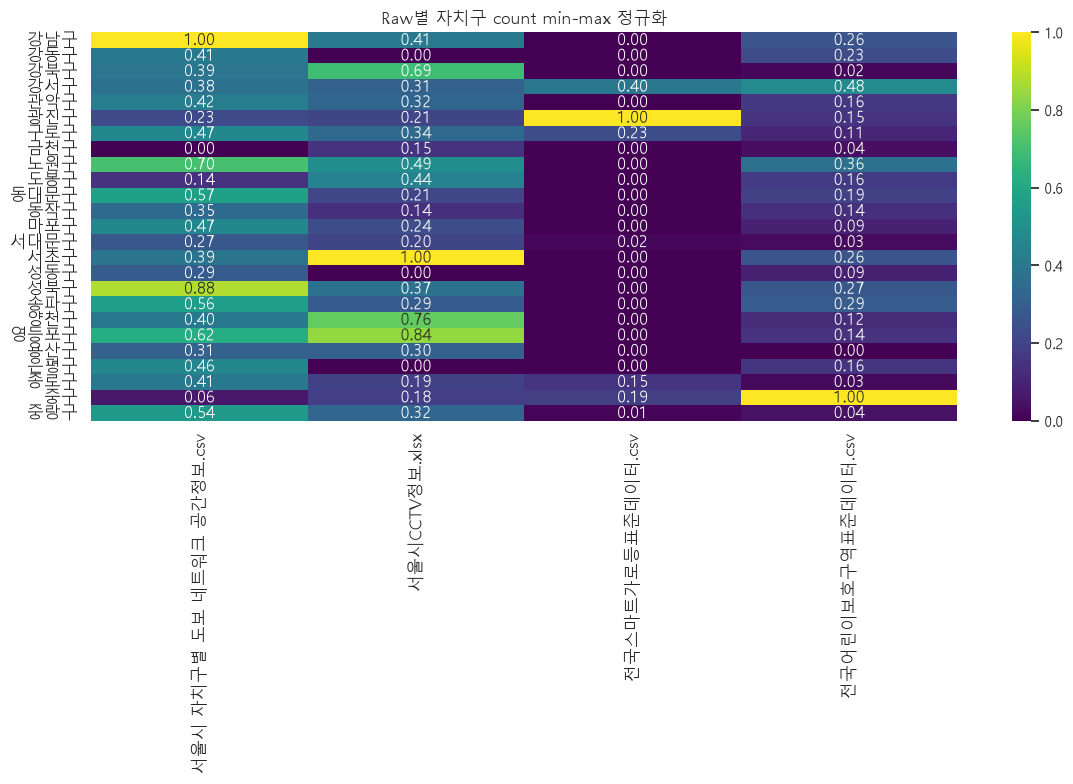

In [23]:
def minmax(series):
    min_value = series.min()
    max_value = series.max()
    if max_value == min_value:
        return pd.Series(0.0, index=series.index)
    return (series - min_value) / (max_value - min_value)


normalized = gu_count.copy()
normalized["count_norm"] = normalized.groupby("raw_name")["count"].transform(minmax)

norm_pivot = normalized.pivot_table(
    index="gu", columns="raw_name", values="count_norm", fill_value=0
).reindex(SEOUL_GU)

plt.figure(figsize=(12, 8))
ax = sns.heatmap(norm_pivot, annot=True, fmt=".2f", cmap="viridis")
ax.set_title("Raw별 자치구 count min-max 정규화")
ax.set_xlabel("")
ax.set_ylabel("")
apply_korean_font(ax)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "raw_gu_normalized_heatmap.png", dpi=160)
plt.show()

## 8. 컬럼별 결측률 확인

각 raw의 컬럼별 결측률을 계산하고 score 사용 가능성을 분류한다.  
결측이 없는 컬럼은 score 후보, 결측이 큰 컬럼은 직접 score보다 보조 해석용으로 본다.

In [27]:
missing_rows = []

for raw_name, df in raw_frames.items():
    for col in df.columns:
        missing_rows.append(
            {
                "raw_name": raw_name,
                "column": col,
                "missing_rate": df[col].isna().mean(),
                "missing_rows": int(df[col].isna().sum()),
            }
        )

missing = pd.DataFrame(missing_rows)


def score_usage(rate):
    if rate == 0:
        return "score 후보"
    if rate <= 0.2:
        return "보조 score 후보"
    return "score 직접 사용 제외"


missing["usage"] = missing["missing_rate"].apply(score_usage)

display(
    missing.sort_values(["raw_name", "missing_rate"], ascending=[True, False]).head(40)
)
missing.to_csv(
    TABLE_DIR / "raw_column_missing_usage.csv", index=False, encoding="utf-8-sig"
)

,raw_name,column,missing_rate,missing_rows,usage
56,서울시 자치구별 도보 네트워크 공간정보.csv,노드 WKT,0.568166,279016,score 직접 사용 제외
58,서울시 자치구별 도보 네트워크 공간정보.csv,노드 유형 코드,0.568166,279016,score 직접 사용 제외
59,서울시 자치구별 도보 네트워크 공간정보.csv,링크 WKT,0.431834,212066,score 직접 사용 제외
61,서울시 자치구별 도보 네트워크 공간정보.csv,링크 유형 코드,0.431834,212066,score 직접 사용 제외
62,서울시 자치구별 도보 네트워크 공간정보.csv,시작노드 ID,0.431834,212066,score 직접 사용 제외
63,서울시 자치구별 도보 네트워크 공간정보.csv,종료노드 ID,0.431834,212066,score 직접 사용 제외
64,서울시 자치구별 도보 네트워크 공간정보.csv,링크 길이,0.431834,212066,score 직접 사용 제외
69,서울시 자치구별 도보 네트워크 공간정보.csv,고가도로,0.431834,212066,score 직접 사용 제외
70,서울시 자치구별 도보 네트워크 공간정보.csv,지하철네트워크,0.431834,212066,score 직접 사용 제외
71,서울시 자치구별 도보 네트워크 공간정보.csv,교량,0.431834,212066,score 직접 사용 제외


## 8-1. 도보 네트워크 NODE/LINK 구조 분리 결측률 확인

도보 네트워크 raw는 `NODE`와 `LINK` 행이 한 파일에 섞여 있으므로, 전체 row 기준 결측률만으로 품질을 판단하면 구조적 결측을 품질 문제로 오해할 수 있다.

따라서 행 유형을 먼저 분리하고, NODE/LINK 각각에서 의미 있는 필수 컬럼만 다시 검사한다.


In [5]:
WALK_RAW_NAME = "서울시 자치구별 도보 네트워크 공간정보.csv"
TYPE_COL = "노드링크 유형"

if "infer_gu" not in globals():
    def infer_gu(df):
        gu_pattern = r"([가-힣]+구)"
        gu_like_cols = [
            col for col in df.columns
            if any(key in col for key in ["시군구명", "자치구", "구명", "주소"])
        ]
        if gu_like_cols:
            text = df[gu_like_cols].astype("string").fillna("").agg(" ".join, axis=1)
        else:
            text = df.astype("string").fillna("").agg(" ".join, axis=1)
        return text.str.extract(gu_pattern, expand=False)

walk = raw_frames[WALK_RAW_NAME].copy()
walk["gu"] = infer_gu(walk)
walk["_node_link_type"] = walk[TYPE_COL].astype("string").str.strip().str.upper()

walk_nodes = walk[walk["_node_link_type"].eq("NODE")].copy()
walk_links = walk[walk["_node_link_type"].eq("LINK")].copy()

node_link_type_summary = (
    walk["_node_link_type"]
    .value_counts(dropna=False)
    .rename_axis("node_link_type")
    .reset_index(name="rows")
)
node_link_type_summary["row_ratio"] = node_link_type_summary["rows"] / len(walk)

display(node_link_type_summary)
node_link_type_summary.to_csv(
    TABLE_DIR / "walk_node_link_type_summary.csv", index=False, encoding="utf-8-sig"
)

node_required_cols = ["노드 WKT", "노드 ID", "노드 유형 코드"]
link_required_cols = ["링크 WKT", "링크 ID", "시작노드 ID", "종료노드 ID", "링크 길이"]
link_special_cols = [
    "고가도로",
    "지하철네트워크",
    "교량",
    "터널",
    "육교",
    "횡단보도",
    "공원_녹지",
    "건물내",
]


def classify_context_missing(rate, required):
    if pd.isna(rate):
        return "검사 불가"
    if required and rate == 0:
        return "필수 컬럼 정상"
    if required:
        return "품질 결측 확인 필요"
    if rate <= 0.2:
        return "보조 score 후보"
    return "선택적/희소 컬럼"


def build_context_missing(df, row_type, columns, required_cols):
    rows = []
    total_rows = len(df)
    for col in columns:
        if col not in df.columns:
            continue
        missing_rows = int(df[col].isna().sum())
        missing_rate = missing_rows / total_rows if total_rows else np.nan
        rows.append(
            {
                "row_type": row_type,
                "column": col,
                "total_rows": total_rows,
                "missing_rows": missing_rows,
                "missing_rate": missing_rate,
                "is_required": col in required_cols,
                "interpretation": classify_context_missing(
                    missing_rate, col in required_cols
                ),
            }
        )
    return rows


context_missing = pd.DataFrame(
    build_context_missing(walk_nodes, "NODE", node_required_cols, node_required_cols)
    + build_context_missing(
        walk_links,
        "LINK",
        link_required_cols + link_special_cols,
        link_required_cols,
    )
)

display(context_missing)
context_missing.to_csv(
    TABLE_DIR / "walk_node_link_context_missing.csv", index=False, encoding="utf-8-sig"
)

structural_missing_checks = pd.DataFrame(
    build_context_missing(walk_nodes, "NODE", link_required_cols, [])
    + build_context_missing(walk_links, "LINK", node_required_cols, [])
)
structural_missing_checks["interpretation"] = "구조적 결측 예상"

display(structural_missing_checks)
structural_missing_checks.to_csv(
    TABLE_DIR / "walk_node_link_structural_missing.csv",
    index=False,
    encoding="utf-8-sig",
)


,node_link_type,rows,row_ratio
0,LINK,279016,0.568166
1,NODE,212066,0.431834


,row_type,column,total_rows,missing_rows,missing_rate,is_required,interpretation
0,NODE,노드 WKT,212066,0,0.0,True,필수 컬럼 정상
1,NODE,노드 ID,212066,0,0.0,True,필수 컬럼 정상
2,NODE,노드 유형 코드,212066,0,0.0,True,필수 컬럼 정상
3,LINK,링크 WKT,279016,0,0.0,True,필수 컬럼 정상
4,LINK,링크 ID,279016,0,0.0,True,필수 컬럼 정상
5,LINK,시작노드 ID,279016,0,0.0,True,필수 컬럼 정상
6,LINK,종료노드 ID,279016,0,0.0,True,필수 컬럼 정상
7,LINK,링크 길이,279016,0,0.0,True,필수 컬럼 정상
8,LINK,고가도로,279016,0,0.0,False,보조 score 후보
9,LINK,지하철네트워크,279016,0,0.0,False,보조 score 후보


,row_type,column,total_rows,missing_rows,missing_rate,is_required,interpretation
0,NODE,링크 WKT,212066,212066,1.0,False,구조적 결측 예상
1,NODE,링크 ID,212066,0,0.0,False,구조적 결측 예상
2,NODE,시작노드 ID,212066,212066,1.0,False,구조적 결측 예상
3,NODE,종료노드 ID,212066,212066,1.0,False,구조적 결측 예상
4,NODE,링크 길이,212066,212066,1.0,False,구조적 결측 예상
5,LINK,노드 WKT,279016,279016,1.0,False,구조적 결측 예상
6,LINK,노드 ID,279016,0,0.0,False,구조적 결측 예상
7,LINK,노드 유형 코드,279016,279016,1.0,False,구조적 결측 예상


## 9. 도보 edge 길이 컬럼 확인

도보 네트워크 raw에서 edge 길이에 해당하는 컬럼 후보를 찾는다.  
도보 edge는 점 데이터가 아니라 선 데이터이므로 row 수보다 총 길이 기준으로 보는 것이 적절하다.

In [6]:
if "walk_links" not in globals():
    WALK_RAW_NAME = "서울시 자치구별 도보 네트워크 공간정보.csv"
    TYPE_COL = "노드링크 유형"
    walk = raw_frames[WALK_RAW_NAME].copy()
    walk["gu"] = infer_gu(walk)
    walk["_node_link_type"] = walk[TYPE_COL].astype("string").str.strip().str.upper()
    walk_nodes = walk[walk["_node_link_type"].eq("NODE")].copy()
    walk_links = walk[walk["_node_link_type"].eq("LINK")].copy()

length_candidates = [
    c for c in walk_links.columns
    if "길이" in c or "연장" in c or "length" in c.lower()
]
length_candidates


['링크 길이']

## 10. 자치구별 도보 edge 총 길이

자치구별 도보 edge 길이를 합산해 km 단위로 시각화한다.  
이를 통해 어느 자치구에 도보 네트워크가 더 많이 분포하는지 row count가 아닌 길이 기준으로 확인한다.

C:\Users\82102\AppData\Local\Temp\ipykernel_15740\2939619932.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


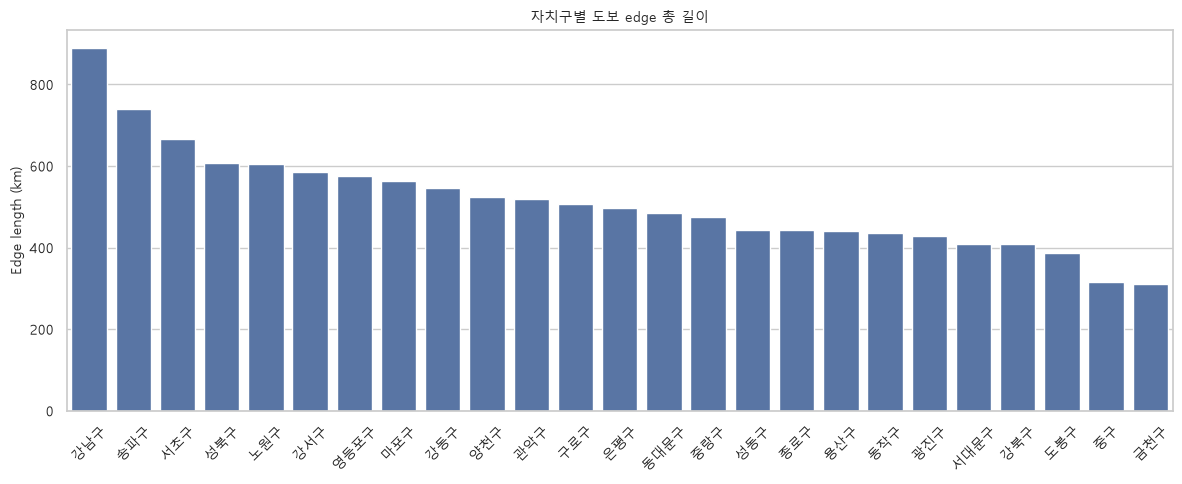

In [7]:
LENGTH_COL = length_candidates[0]

walk_links[LENGTH_COL] = pd.to_numeric(walk_links[LENGTH_COL], errors="coerce")

walk_length = (
    walk_links.dropna(subset=["gu"])
    .query("gu in @SEOUL_GU")
    .groupby("gu")[LENGTH_COL]
    .sum()
    .reset_index(name="edge_length_m")
)

walk_length["edge_length_km"] = walk_length["edge_length_m"] / 1000

plt.figure(figsize=(12, 5))
ax = sns.barplot(
    data=walk_length.sort_values("edge_length_km", ascending=False),
    x="gu",
    y="edge_length_km",
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title("자치구별 도보 edge 총 길이")
ax.set_xlabel("")
ax.set_ylabel("Edge length (km)")
apply_korean_font(ax)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "walk_edge_length_by_gu.png", dpi=160)
plt.show()

## 10-1. 자치구 면적 대비 도보 edge 길이 density

10번의 도보 edge 총 길이는 자치구별 총량이므로 면적이 넓은 구가 유리할 수 있다.  
따라서 자치구 면적값을 붙여 edge_length_km / area_km2 기준의 길이 밀도를 계산한다.

,gu,edge_length_m,edge_length_km,area_km2,edge_length_density_km_per_km2
0,동대문구,485972.184,485.972184,14.22,34.175259
1,중구,316089.149,316.089149,9.96,31.735858
2,양천구,524373.597,524.373597,17.41,30.119104
3,동작구,435071.065,435.071065,16.36,26.593586
4,성동구,443798.301,443.798301,16.82,26.385155
5,중랑구,475329.359,475.329359,18.50,25.693479
6,구로구,506760.213,506.760213,20.12,25.186889
7,광진구,427705.328,427.705328,17.06,25.070652
8,성북구,607395.572,607.395572,24.59,24.700918
9,금천구,310464.116,310.464116,13.02,23.845170


C:\Users\82102\AppData\Local\Temp\ipykernel_33376\2637776155.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


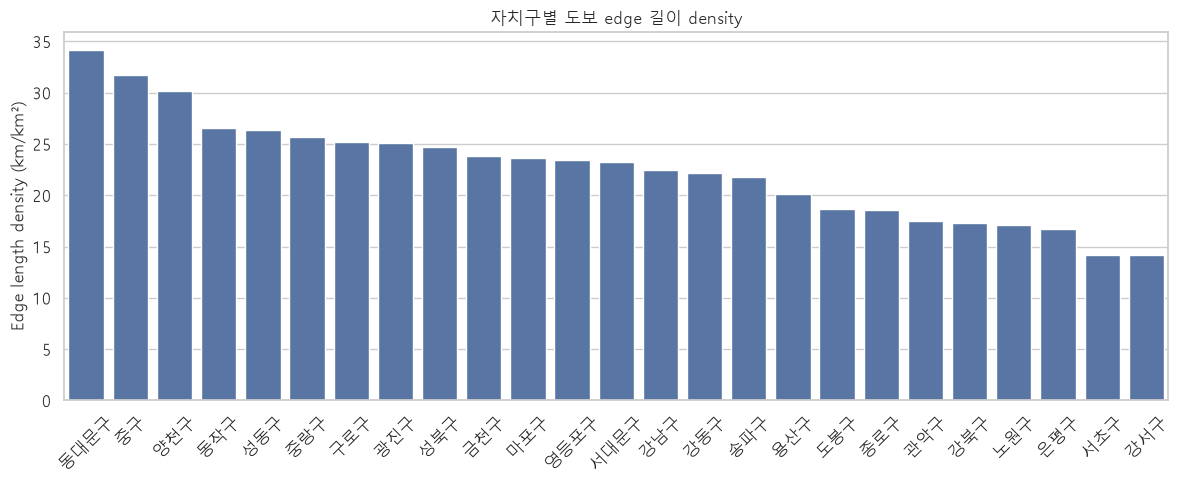

In [32]:
walk_length_density = walk_length.merge(gu_area, on="gu", how="left")
walk_length_density["edge_length_density_km_per_km2"] = (
    walk_length_density["edge_length_km"] / walk_length_density["area_km2"]
)

display(
    walk_length_density
    .sort_values("edge_length_density_km_per_km2", ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(12, 5))
ax = sns.barplot(
    data=walk_length_density.sort_values("edge_length_density_km_per_km2", ascending=False),
    x="gu",
    y="edge_length_density_km_per_km2",
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title("자치구별 도보 edge 길이 density")
ax.set_xlabel("")
ax.set_ylabel("Edge length density (km/km²)")
apply_korean_font(ax)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "walk_edge_length_density_by_gu.png", dpi=160)
plt.show()

walk_length_density.to_csv(
    TABLE_DIR / "walk_edge_length_density_by_gu.csv",
    index=False,
    encoding="utf-8-sig",
)

## 11. 도보 edge 특수 속성 비율

고가도로, 교량, 터널, 육교, 횡단보도, 공원/녹지, 건물내 같은 0/1 속성의 비율을 계산한다.  

non_null_rows가 아니라 실제로 값이 1인 row 수와 비율이 핵심이다.

In [8]:
special_cols = [
    "고가도로",
    "지하철네트워크",
    "교량",
    "터널",
    "육교",
    "횡단보도",
    "공원_녹지",
    "건물내",
]
special_cols = [c for c in special_cols if c in walk.columns]

special_summary = []

for col in special_cols:
    values = pd.to_numeric(walk_links[col], errors="coerce")
    value_1_rows = int((values == 1).sum())
    value_1_ratio = float((values == 1).mean())
    special_summary.append(
        {
            "column": col,
            "total_edges": len(walk_links),
            "nnon_null_rows": int(values.notna().sum()),
            "value_1_rows": value_1_rows,
            "value_1_ratio": value_1_ratio,
            "value_1_percent": value_1_ratio * 100,
            "edges_per_1": round(1 / value_1_ratio, 1) if value_1_ratio > 0 else np.nan,
        }
    )

special_summary = pd.DataFrame(special_summary)
special_summary["score_usage_note"] = np.select(
    [
        special_summary["value_1_ratio"] >= 0.05,
        special_summary["value_1_ratio"] >= 0.01,
    ],
    [
        "자치구별 비교 후보",
        "보조 해석 후보",
    ],
    default="희소 속성: score 주지표 제외",
)

display(special_summary.sort_values("value_1_ratio", ascending=False))

special_summary.to_csv(
    TABLE_DIR / "walk_edge_special_attr_summary.csv", index=False, encoding="utf-8-sig"
)

,column,total_edges,nnon_null_rows,value_1_rows,value_1_ratio,value_1_percent,edges_per_1,score_usage_note
6,건물내,279016,279016,11561,0.041435,4.143490,24.1,보조 해석 후보
5,횡단보도,279016,279016,7898,0.028307,2.830662,35.3,보조 해석 후보
0,고가도로,279016,279016,2831,0.010146,1.014637,98.6,보조 해석 후보
4,육교,279016,279016,1459,0.005229,0.522909,191.2,희소 속성: score 주지표 제외
2,교량,279016,279016,576,0.002064,0.206440,484.4,희소 속성: score 주지표 제외
3,터널,279016,279016,181,0.000649,0.064871,1541.5,희소 속성: score 주지표 제외
1,지하철네트워크,279016,279016,174,0.000624,0.062362,1603.5,희소 속성: score 주지표 제외


## 12. 자치구별 도보 edge 특수 속성 heatmap

특수 속성 값이 1인 edge 비율을 자치구별 heatmap으로 확인한다.  
공원/녹지, 교량, 터널 등 일반 도로망만으로 설명하기 어려운 보행공간이 어느 자치구에 많은지 1차로 볼 수 있다.

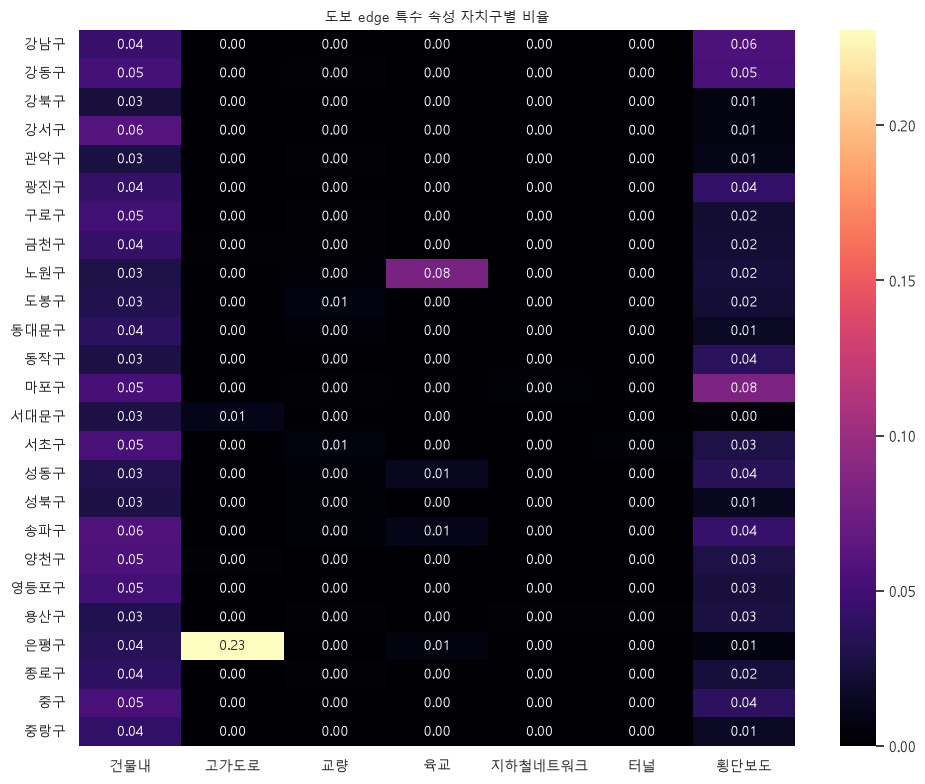

In [9]:
special_by_gu = []

for col in special_cols:
    temp = walk_links.dropna(subset=["gu"]).query("gu in @SEOUL_GU").copy()
    temp[col] = pd.to_numeric(temp[col], errors="coerce")
    ratio = (
        temp.groupby("gu")[col]
        .apply(lambda s: (s == 1).mean())
        .reset_index(name="ratio")
    )
    ratio["attribute"] = col
    special_by_gu.append(ratio)

special_by_gu = pd.concat(special_by_gu, ignore_index=True)

special_pivot = special_by_gu.pivot_table(
    index="gu", columns="attribute", values="ratio", fill_value=0
).reindex(SEOUL_GU)

plt.figure(figsize=(10, 8))
ax = sns.heatmap(special_pivot, annot=True, fmt=".2f", cmap="magma")
ax.set_title("도보 edge 특수 속성 자치구별 비율")
ax.set_xlabel("")
ax.set_ylabel("")
apply_korean_font(ax)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "walk_edge_special_attr_ratio_heatmap.png", dpi=160)
plt.show()

## 12-1. 공원/녹지 및 하천 주변 검증 필요 항목 정리

12번 heatmap은 도보 edge raw 안의 0/1 속성만 집계한 결과다.  
이 값만으로 실제 공원 내부 보행로인지, 하천 주변 보행로인지 확정할 수 없으므로 spatial join 또는 지도 overlay 검증 항목으로 분리한다.

In [10]:
spatial_validation_targets = pd.DataFrame(
    [
        {
            "target": "공원/녹지 보행로",
            "current_signal": "도보 edge의 공원_녹지 속성값",
            "current_limit": "속성값만으로 실제 공원 polygon 내부/인접 여부를 확정할 수 없음",
            "next_check": "서울시 주요 공원현황 또는 공원 polygon과 spatial join/overlay",
        },
        {
            "target": "하천 주변 보행로",
            "current_signal": "도보 edge의 교량/터널/고가도로 등 특수 속성 및 위치",
            "current_limit": "현재 특수 속성만으로 하천 주변 여부를 판단할 수 없음",
            "next_check": "서울시 하천 GeoJSON 주변 buffer 생성 후 도보 edge와 spatial join",
        },
    ]
)

display(spatial_validation_targets)
spatial_validation_targets.to_csv(
    TABLE_DIR / "walk_edge_spatial_validation_targets.csv",
    index=False,
    encoding="utf-8-sig",
)

,target,current_signal,current_limit,next_check
0,공원/녹지 보행로,도보 edge의 공원_녹지 속성값,속성값만으로 실제 공원 polygon 내부/인접 여부를 확정할 수 없음,서울시 주요 공원현황 또는 공원 polygon과 spatial join/overlay
1,하천 주변 보행로,도보 edge의 교량/터널/고가도로 등 특수 속성 및 위치,현재 특수 속성만으로 하천 주변 여부를 판단할 수 없음,서울시 하천 GeoJSON 주변 buffer 생성 후 도보 edge와 spatial...


## 13. 1차 해석

- raw별 전체 row 수 차이가 커서 단순 count 비교는 부적절하다.
- 자치구별 count는 분포 확인에는 유용하지만, 비교 지표로 쓰려면 density 또는 정규화가 필요하다.
- 결측률이 큰 부가 컬럼은 score 직접 사용보다 보조 해석용으로 제한한다.
- 도보 edge는 row 수보다 edge 총 길이와 특수 속성 비율로 해석하는 것이 적절하다.
- 특수 속성이 실제 공원/하천 주변과 겹치는지는 추후 spatial join 또는 지도 overlay로 검증해야 한다.